# Reproducible OCR-Assisted PubLayNet Benchmark

Pipeline:

> **PubLayNet image -> OCR -> searchable PDF/text layer -> PyMuPDF4LLM layout detection -> IoU matching -> metrics**

This notebook runs the OCR benchmark from scratch on the same 10 sample IDs used by the project. It downloads the images and annotations from Hugging Face during the run, creates fresh OCR-assisted PDFs in memory, and never reads prior prediction, metric, or summary files. Tesseract is used only to create the text layer; final layout classes and boxes come from PyMuPDF Layout.

In [1]:
from collections import Counter
from pathlib import Path
from time import perf_counter
import json
import shutil
import sys

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pandas as pd
from PIL import Image
import pymupdf
import pymupdf4llm  # Activates PyMuPDF Layout.
import pytesseract
from datasets import load_dataset

print("Python:", sys.version.split()[0])
print("PyMuPDF:", pymupdf.__version__)
print("PyMuPDF4LLM:", pymupdf4llm.version)
print("pytesseract:", pytesseract.__version__)
print("datasets:", __import__("datasets").__version__)

for package_name in ("pymupdf", "pymupdf4llm", "pytesseract", "datasets", "pandas", "Pillow"):
    print(f"{package_name}: available")

tesseract_command = shutil.which("tesseract")
if not tesseract_command:
    raise RuntimeError(
        "Tesseract was not found with shutil.which('tesseract'). "
        "Install Tesseract OCR and add its installation folder to PATH, "
        "then restart VS Code/Jupyter before running this notebook."
    )
pytesseract.pytesseract.tesseract_cmd = tesseract_command
print("Tesseract executable:", tesseract_command)
print("Tesseract version:", str(pytesseract.get_tesseract_version()))

C:\Users\oscar\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.13.7
PyMuPDF: 1.28.2
PyMuPDF4LLM: 1.28.2
pytesseract: 0.3.13
datasets: 5.0.1
pymupdf: available
pymupdf4llm: available
pytesseract: available
datasets: available
pandas: available
Pillow: available
Tesseract executable: C:\Program Files\Tesseract-OCR\tesseract.EXE
Tesseract version: 5.5.3.20260724


In [2]:
def find_repo_root(start_path=None):
    """Find the repository root without assuming a notebooks/ parent folder."""
    start = Path(start_path or Path.cwd()).resolve()
    candidates = (start, *start.parents)

    for candidate in candidates:
        has_readme = (candidate / "README.md").is_file()
        has_new_layout = all((candidate / name).is_dir() for name in ("people", "shared", "weekly"))
        has_current_layout = all((candidate / name).is_dir() for name in ("data", "notebooks", "outputs"))
        if has_readme and (has_new_layout or has_current_layout):
            return candidate

    raise RuntimeError(
        "Could not find the repository root. Start the notebook from the repository "
        "or a child folder. Expected README.md plus people/shared/weekly (new layout) "
        "or data/notebooks/outputs (current layout)."
    )


ROOT = find_repo_root()
DATA_DIR = ROOT / "data" / "publaynet_sample"
OUTPUT_DIR = ROOT / "outputs" / "publaynet"
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATASET_NAME = "jordanparker6/publaynet"
SPLIT = "validation"
IOU_THRESHOLD = 0.50
TARGET_IDS = [
    "409598", "410520", "415658", "415213", "415214",
    "415603", "415605", "415608", "415196", "415197",
]

PUBLAYNET_ID_TO_CLASS = {
    1: "text", 2: "title", 3: "list", 4: "table", 5: "figure",
}
PYMUPDF_TO_PUBLAYNET = {
    "text": "text", "caption": "text", "footnote": "text",
    "page-header": "text", "page-footer": "text",
    "title": "title", "section-header": "title",
    "list-item": "list", "table": "table", "picture": "figure",
}
CLASSES = ["text", "title", "list", "table", "figure"]

stream = load_dataset(DATASET_NAME, split=SPLIT, streaming=True)
target_set = set(TARGET_IDS)
samples_by_id = {}
for sample in stream:
    sample_id = str(sample["id"])
    if sample_id in target_set:
        samples_by_id[sample_id] = sample
    if len(samples_by_id) == len(TARGET_IDS):
        break

missing_ids = [sample_id for sample_id in TARGET_IDS if sample_id not in samples_by_id]
if missing_ids:
    raise RuntimeError(f"Dataset did not provide target sample IDs: {missing_ids}")

samples = [samples_by_id[sample_id] for sample_id in TARGET_IDS]
print("Repository root:", ROOT)
print("Data directory:", DATA_DIR)
print("Output directory:", OUTPUT_DIR)
print(f"Downloaded {len(samples)} samples from {DATASET_NAME}/{SPLIT}.")

Repository root: C:\Users\oscar\Documents\CMU\Mini 5\Capstone\pymupdf4llm-benchmark
Data directory: C:\Users\oscar\Documents\CMU\Mini 5\Capstone\pymupdf4llm-benchmark\data\publaynet_sample
Output directory: C:\Users\oscar\Documents\CMU\Mini 5\Capstone\pymupdf4llm-benchmark\outputs\publaynet
Downloaded 10 samples from jordanparker6/publaynet/validation.


In [3]:
from pymupdf4llm.ocr import tesseract_api


def coco_to_xyxy(bbox):
    x, y, width, height = map(float, bbox)
    return [x, y, x + width, y + height]


def ground_truth_for(sample):
    boxes = []
    for annotation in sample["annotations"]:
        if int(annotation.get("iscrowd", 0)):
            continue
        boxes.append({
            "class": PUBLAYNET_ID_TO_CLASS[int(annotation["category_id"])],
            "bbox": coco_to_xyxy(annotation["bbox"]),
        })
    return boxes


def make_image_pdf(image_path):
    """Create a fresh one-page PDF containing the PubLayNet image."""
    with pymupdf.open(str(image_path)) as image_document:
        pdf_bytes = image_document.convert_to_pdf()
    return pymupdf.open("pdf", pdf_bytes)


def map_layout_boxes(raw_boxes, page_size, image_size):
    page_width, page_height = map(float, page_size)
    image_width, image_height = map(float, image_size)
    scale_x = image_width / page_width
    scale_y = image_height / page_height
    predictions = []
    ignored_classes = Counter()
    for raw_box in raw_boxes:
        raw_class = raw_box["class_name"]
        mapped_class = PYMUPDF_TO_PUBLAYNET.get(raw_class)
        if mapped_class is None:
            ignored_classes[raw_class] += 1
            continue
        x0, y0, x1, y1 = map(float, raw_box["group_bbox"])
        predictions.append({
            "class": mapped_class,
            "raw_class": raw_class,
            "bbox": [x0 * scale_x, y0 * scale_y, x1 * scale_x, y1 * scale_y],
        })
    return predictions, dict(ignored_classes)

In [4]:
records = []
for sample in samples:
    sample_id = str(sample["id"])
    image = sample["image"].convert("RGB")
    image_path = DATA_DIR / f"publaynet_{sample_id}.png"
    image.save(image_path)
    ground_truth = ground_truth_for(sample)
    start = perf_counter()

    ocr_pdf = make_image_pdf(image_path)
    try:
        result = pymupdf4llm.to_markdown(
            ocr_pdf,
            page_chunks=True,
            use_ocr=True,
            force_ocr=True,
            ocr_function=tesseract_api.exec_ocr,
            ocr_language="eng",
            ocr_dpi=300,
        )
        page = ocr_pdf[0]
        page.get_layout(return_raw=True)
        raw_boxes = page.layout_information or []
        if not raw_boxes:
            raise RuntimeError("No layout boxes returned after OCR.")
        predictions, ignored_classes = map_layout_boxes(
            raw_boxes,
            (page.rect.width, page.rect.height),
            (image.width, image.height),
        )
        if not predictions:
            raise RuntimeError("No mapped layout predictions returned.")
        text = result[0].get("text", "") if result else ""
        records.append({
            "sample_id": sample_id,
            "image_path": str(image_path),
            "image_size": [image.width, image.height],
            "ground_truth": ground_truth,
            "predictions": predictions,
            "raw_boxes": len(raw_boxes),
            "raw_classes": dict(Counter(box["class_name"] for box in raw_boxes)),
            "ignored_classes": ignored_classes,
            "ocr_word_count": len(text.split()),
            "ocr_mean_confidence": None,
            "text_preview": text[:500],
            "page_size": [float(page.rect.width), float(page.rect.height)],
            "runtime_seconds": perf_counter() - start,
            "error": None,
        })
    except Exception as error:
        records.append({
            "sample_id": sample_id,
            "image_path": str(image_path),
            "image_size": [image.width, image.height],
            "ground_truth": ground_truth,
            "predictions": [],
            "raw_boxes": 0,
            "raw_classes": {},
            "ignored_classes": {},
            "ocr_word_count": 0,
            "ocr_mean_confidence": None,
            "text_preview": "",
            "page_size": [float(image.width), float(image.height)],
            "runtime_seconds": perf_counter() - start,
            "error": repr(error),
        })
    finally:
        ocr_pdf.close()

print("First page text preview:")
print(records[0]["text_preview"])
print("First page raw classes:", records[0]["raw_classes"])
print("First page raw boxes:", records[0]["raw_boxes"])
print("First page mapped predictions:", len(records[0]["predictions"]))
print("First page runtime seconds:", round(records[0]["runtime_seconds"], 3))
print("Pages processed:", len(records))


=== Document parser messages ===


OCR on page.number=0/1.



=== Document parser messages ===


OCR on page.number=0/1.



=== Document parser messages ===


...


=== Document parser messages ===


OCR on page.number=0/1.



=== Document parser messages ===


OCR on page.number=0/1.


First page text preview:
Thrombosis Jounal 2005, 3:5 

http: ihwaew thromiboelepoucom co **n** tent4i'5nall 

Table |: Gistribuchom of 10 clindcally and § genetically relevant variables in a cohort of young women at baseline of the observational period 1793 = 2003. The total number of wormen in this analysis is 4320, Le. cocluding 17 women with a final diagnosis of a possible! potential VTE. Deviations from this number are due to modssing data 

|Variables||||
|---|---|---|---|
|Concinvuouswariabhes<br>||hh<br>|Mean (8D
First page raw classes: {'page-header': 2, 'caption': 1, 'table': 1, 'text': 4, 'page-footer': 1}
First page raw boxes: 9
First page mapped predictions: 9
First page runtime seconds: 3.72
Pages processed: 10


In [5]:
def intersection_over_union(box_a, box_b):
    ax0, ay0, ax1, ay1 = box_a
    bx0, by0, bx1, by1 = box_b
    intersection = max(0.0, min(ax1, bx1) - max(ax0, bx0)) * max(
        0.0, min(ay1, by1) - max(ay0, by0)
    )
    area_a = max(0.0, ax1 - ax0) * max(0.0, ay1 - ay0)
    area_b = max(0.0, bx1 - bx0) * max(0.0, by1 - by0)
    union = area_a + area_b - intersection
    return intersection / union if union else 0.0


def match_one_class(ground_truth, predictions):
    candidates = [
        (intersection_over_union(gt, prediction), gt_index, prediction_index)
        for gt_index, gt in enumerate(ground_truth)
        for prediction_index, prediction in enumerate(predictions)
    ]
    candidates.sort(reverse=True)
    matched_gt = set()
    matched_predictions = set()
    matched_ious = []
    for iou, gt_index, prediction_index in candidates:
        if iou < IOU_THRESHOLD:
            break
        if gt_index in matched_gt or prediction_index in matched_predictions:
            continue
        matched_gt.add(gt_index)
        matched_predictions.add(prediction_index)
        matched_ious.append(iou)
    true_positive = len(matched_ious)
    return true_positive, len(predictions) - true_positive, len(ground_truth) - true_positive, matched_ious


totals = {class_name: {"tp": 0, "fp": 0, "fn": 0, "ious": []} for class_name in CLASSES}
per_page_rows = []
for record in records:
    if record["error"]:
        continue
    page_counts = {"tp": 0, "fp": 0, "fn": 0}
    for class_name in CLASSES:
        ground_truth = [box["bbox"] for box in record["ground_truth"] if box["class"] == class_name]
        predictions = [box["bbox"] for box in record["predictions"] if box["class"] == class_name]
        tp, fp, fn, ious = match_one_class(ground_truth, predictions)
        totals[class_name]["tp"] += tp
        totals[class_name]["fp"] += fp
        totals[class_name]["fn"] += fn
        totals[class_name]["ious"].extend(ious)
        page_counts["tp"] += tp
        page_counts["fp"] += fp
        page_counts["fn"] += fn
    per_page_rows.append({
        "sample_id": record["sample_id"],
        "ground_truth_boxes": len(record["ground_truth"]),
        "predicted_boxes": len(record["predictions"]),
        **page_counts,
        "ocr_word_count": record["ocr_word_count"],
        "ocr_mean_confidence": record["ocr_mean_confidence"],
        "runtime_seconds": record["runtime_seconds"],
    })

metric_rows = []
for class_name in CLASSES:
    values = totals[class_name]
    tp, fp, fn = values["tp"], values["fp"], values["fn"]
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    metric_rows.append({
        "class": class_name,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "mean_matched_iou": sum(values["ious"]) / len(values["ious"]) if values["ious"] else 0.0,
    })

metrics_df = pd.DataFrame(metric_rows)
per_page_df = pd.DataFrame(per_page_rows)
summary = {
    "dataset": DATASET_NAME,
    "split": SPLIT,
    "sample_ids": TARGET_IDS,
    "pathway": "PubLayNet image -> Tesseract OCR -> searchable PDF text layer -> PyMuPDF Layout",
    "pages": len(records),
    "successful_pages": sum(record["error"] is None for record in records),
    "failed_pages": sum(record["error"] is not None for record in records),
    "iou_threshold": IOU_THRESHOLD,
    "macro_precision": float(metrics_df["precision"].mean()),
    "macro_recall": float(metrics_df["recall"].mean()),
    "macro_f1": float(metrics_df["f1"].mean()),
    "mean_runtime_seconds": float(per_page_df["runtime_seconds"].mean()),
    "p95_runtime_seconds": float(per_page_df["runtime_seconds"].quantile(0.95)),
    "mean_ocr_confidence": None,
}

metrics_df

,class,tp,fp,fn,precision,recall,f1,mean_matched_iou
0,text,19,40,91,0.322034,0.172727,0.224852,0.869737
1,title,3,7,15,0.300000,0.166667,0.214286,0.763417
2,list,0,6,5,0.000000,0.000000,0.000000,0.000000
3,table,5,0,2,1.000000,0.714286,0.833333,0.955003
4,figure,0,1,0,0.000000,0.000000,0.000000,0.000000


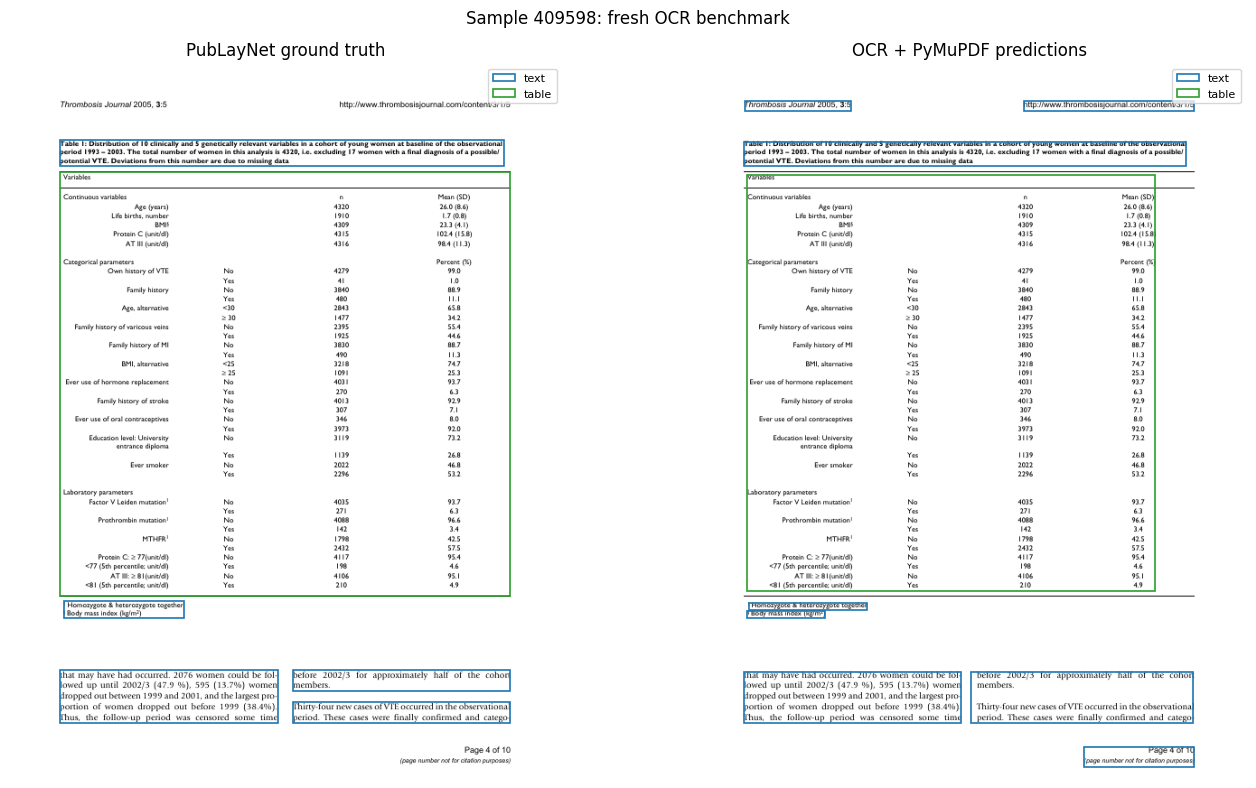

{
  "dataset": "jordanparker6/publaynet",
  "split": "validation",
  "sample_ids": [
    "409598",
    "410520",
    "415658",
    "415213",
    "415214",
    "415603",
    "415605",
    "415608",
    "415196",
    "415197"
  ],
  "pathway": "PubLayNet image -> Tesseract OCR -> searchable PDF text layer -> PyMuPDF Layout",
  "pages": 10,
  "successful_pages": 10,
  "failed_pages": 0,
  "iou_threshold": 0.5,
  "macro_precision": 0.32440677966101694,
  "macro_recall": 0.21073593073593075,
  "macro_f1": 0.2544942237249929,
  "mean_runtime_seconds": 6.781795429998601,
  "p95_runtime_seconds": 8.471760275003179,
  "mean_ocr_confidence": null
}
Saved fresh outputs to: C:\Users\oscar\Documents\CMU\Mini 5\Capstone\pymupdf4llm-benchmark\outputs\publaynet


In [6]:
CLASS_COLORS = {
    "text": "tab:blue", "title": "tab:orange", "list": "tab:purple",
    "table": "tab:green", "figure": "tab:red",
}


def draw_boxes(axis, image, boxes, title):
    axis.imshow(image)
    axis.set_title(title)
    axis.axis("off")
    used_labels = set()
    for box in boxes:
        class_name = box["class"]
        x0, y0, x1, y1 = box["bbox"]
        label = class_name if class_name not in used_labels else None
        used_labels.add(class_name)
        axis.add_patch(Rectangle(
            (x0, y0), x1 - x0, y1 - y0,
            fill=False, linewidth=1.2,
            edgecolor=CLASS_COLORS[class_name], label=label,
        ))
    if used_labels:
        axis.legend(loc="upper right", fontsize=8)


first_record = records[0]
reference_image = Image.open(first_record["image_path"]).convert("RGB")
figure, axes = plt.subplots(1, 2, figsize=(14, 8))
draw_boxes(axes[0], reference_image, first_record["ground_truth"], "PubLayNet ground truth")
draw_boxes(axes[1], reference_image, first_record["predictions"], "OCR + PyMuPDF predictions")
figure.suptitle(f"Sample {first_record['sample_id']}: fresh OCR benchmark")
figure.tight_layout()
visualization_path = OUTPUT_DIR / "ocr_prediction_vs_ground_truth.png"
figure.savefig(visualization_path, dpi=120)
plt.show()
plt.close(figure)

predictions_path = OUTPUT_DIR / "ocr_fresh_predictions.json"
metrics_path = OUTPUT_DIR / "ocr_fresh_class_metrics.csv"
per_page_path = OUTPUT_DIR / "ocr_fresh_per_page_metrics.csv"
summary_path = OUTPUT_DIR / "ocr_fresh_summary.json"

predictions_path.write_text(json.dumps(records, indent=2), encoding="utf-8")
metrics_df.to_csv(metrics_path, index=False)
per_page_df.to_csv(per_page_path, index=False)
summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")

print(json.dumps(summary, indent=2))
print("Saved fresh outputs to:", OUTPUT_DIR)

In [7]:
expected_output_paths = [predictions_path, metrics_path, per_page_path, summary_path, visualization_path]
failed_records = [record for record in records if record["error"]]

if len(records) != 10:
    raise RuntimeError(f"Expected exactly 10 processed pages, found {len(records)}")
if failed_records:
    raise RuntimeError(f"Pages failed during this run: {failed_records}")
if any(not record["predictions"] for record in records):
    raise RuntimeError("At least one page returned no predictions.")
if any(not path.exists() or path.stat().st_size == 0 for path in expected_output_paths):
    raise RuntimeError("One or more fresh output files were not created.")

print("VALIDATION PASSED")
print("Pages processed:", len(records))
print("All pages succeeded: True")
print("All pages have predictions: True")
print("Output files created: True")

VALIDATION PASSED
Pages processed: 10
All pages succeeded: True
All pages have predictions: True
Output files created: True
